## CNN on Fashion-MNIST

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

In [2]:
torch.manual_seed(42)

In [30]:
df = pd.read_csv('/content/fashion-mnist_train.csv')

In [31]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [32]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
df.shape

(8526, 785)

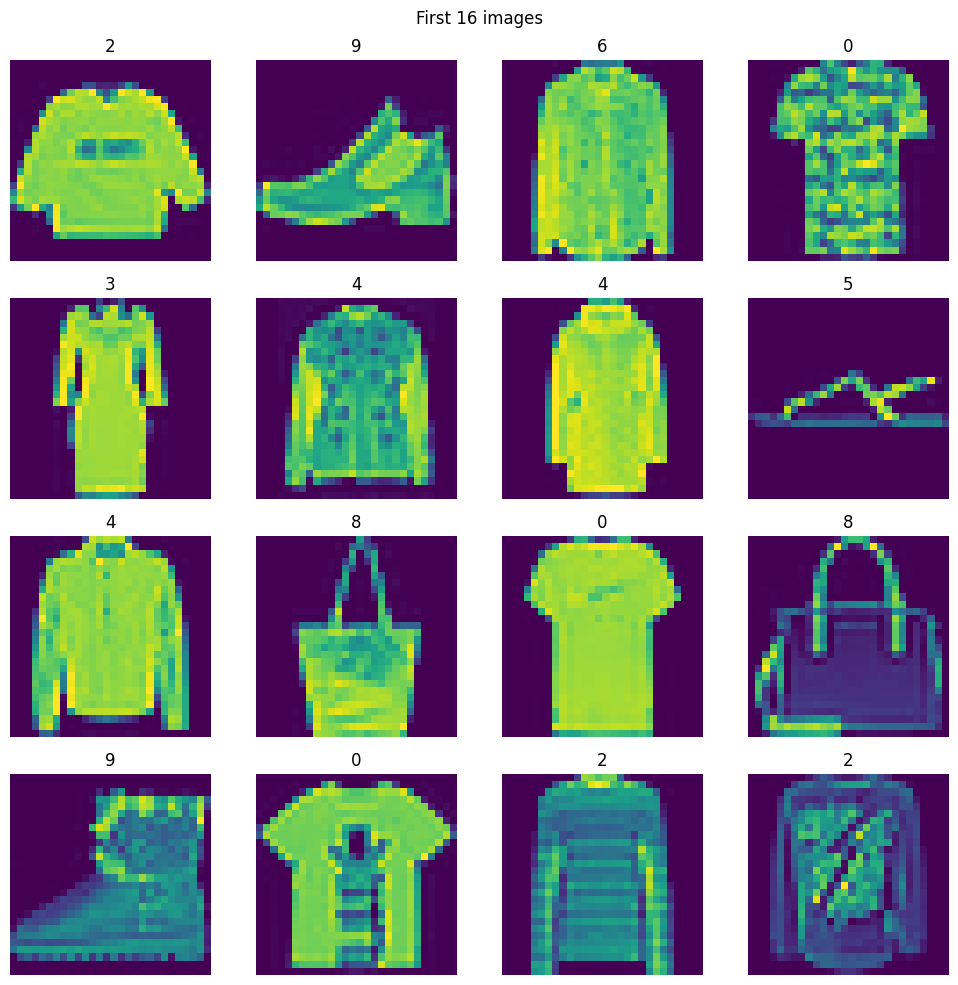

In [34]:
fig, ax = plt.subplots(4,4, figsize=(10,10))
fig.suptitle('First 16 images')

for i, axes in enumerate(ax.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  axes.imshow(img)
  axes.axis('off')
  axes.set_title(df.iloc[i,0])

plt.tight_layout()
plt.show()

In [8]:
X = df.iloc[:, 1:].values
y = df.iloc[:,0].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train = X_train/255.0
X_test = X_test/255.0

In [11]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [12]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [17]:
class myNN(nn.Module):
  def __init__(self, input_features):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(in_channels=input_features, out_channels=32, kernel_size=3, stride=1, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(num_features=32),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(num_features=64),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),

        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(64, 10)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [18]:
epochs = 100
learning_rate = 0.01

In [19]:
model = myNN(1)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-3)

In [21]:
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_features, batch_labels in train_loader:

      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      predictions = model(batch_features)

      loss = criterion(predictions, batch_labels)

      optimizer.zero_grad()

      loss.backward()

      # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

      optimizer.step()

      epoch_loss += loss.item()
    if epoch % 10 == 0:
      print(f"Epoch {epoch}: loss = {epoch_loss / len(train_loader):.4f}")

Epoch 0: loss = 0.1133
Epoch 10: loss = 0.0272
Epoch 20: loss = 0.0138
Epoch 30: loss = 0.0087
Epoch 40: loss = 0.0062
Epoch 50: loss = 0.0066
Epoch 60: loss = 0.0061
Epoch 70: loss = 0.0048
Epoch 80: loss = 0.0035
Epoch 90: loss = 0.0042


In [27]:
model.eval()

myNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [28]:
total = 0
correct = 0

with torch.inference_mode():

    for test_features, test_labels in test_loader:

      test_features, test_labels = test_features.to(device), test_labels.to(device)
      outputs = model(test_features)

      _,prediction = torch.max(outputs, 1)

      total += test_labels.shape[0]
      correct += (prediction == test_labels).sum().item()

    accuracy = correct/total
    print(f"Test accuracy: {accuracy:.4f}")


Test accuracy: 0.9885


In [29]:
total = 0
correct = 0

with torch.inference_mode():

    for batch_features, batch_labels in train_loader:

      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
      outputs = model(batch_features)

      _,prediction = torch.max(outputs, 1)

      total += batch_labels.shape[0]
      correct += (prediction == batch_labels).sum().item()

    accuracy = correct/total
    print(f"Train accuracy: {accuracy:.4f}")

Test accuracy: 1.0000
